In [18]:

import pandas as pd

df = pd.read_excel("/content/veda_day22_cohort_retention_dataset.xlsx")

print("Dataset shape:", df.shape)
print("Unique customers:", df["customer_id"].nunique())
display(df.head())
print(df.isnull().sum())

Dataset shape: (44, 5)
Unique customers: 24


,customer_id,signup_date,order_date,order_id,order_amount
0,C001,2025-01-05,2025-01-08,ORD1001,420
1,C001,2025-01-05,2025-02-03,ORD1002,350
2,C001,2025-01-05,2025-03-11,ORD1003,610
3,C001,2025-01-05,2025-04-02,ORD1004,280
4,C002,2025-01-12,2025-01-15,ORD1005,190


customer_id     0
signup_date     0
order_date      0
order_id        0
order_amount    0
dtype: int64


In [19]:

# Convert date columns to datetime format
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["order_date"] = pd.to_datetime(df["order_date"])

# Create signup month cohort
df["cohort_month"] = (
    df["signup_date"].dt.to_period("M")
)

# Create order activity month
df["order_month"] = (
    df["order_date"].dt.to_period("M")
)

# Display results
display(df[[
    "customer_id",
    "signup_date",
    "order_date",
    "cohort_month",
    "order_month"
]].head(10))

,customer_id,signup_date,order_date,cohort_month,order_month
0,C001,2025-01-05,2025-01-08,2025-01,2025-01
1,C001,2025-01-05,2025-02-03,2025-01,2025-02
2,C001,2025-01-05,2025-03-11,2025-01,2025-03
3,C001,2025-01-05,2025-04-02,2025-01,2025-04
4,C002,2025-01-12,2025-01-15,2025-01,2025-01
5,C002,2025-01-12,2025-02-18,2025-01,2025-02
6,C003,2025-01-20,2025-01-22,2025-01,2025-01
7,C003,2025-01-20,2025-03-04,2025-01,2025-03
8,C004,2025-01-24,2025-01-27,2025-01,2025-01
9,C004,2025-01-24,2025-02-07,2025-01,2025-02


In [20]:

# Step 1: Calculate months since signup
df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["order_month"].dt.month - df["cohort_month"].dt.month)
)

# Step 2: Count unique active customers
cohort_data = df.groupby(
    ["cohort_month", "cohort_index"]
)["customer_id"].nunique().reset_index()

# Step 3: Create cohort table
cohort_table = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

# Step 4: Calculate original cohort size
cohort_size = df.groupby(
    "cohort_month"
)["customer_id"].nunique()

# Step 5: Calculate retention percentage
retention_table = cohort_table.div(
    cohort_size, axis=0
) * 100

print("COHORT CUSTOMER TABLE")
display(cohort_table)

print("RETENTION TABLE (%)")
display(retention_table.round(2))

COHORT CUSTOMER TABLE


cohort_index,0,1,2,3
cohort_month,,,,
2025-01,6.0,4.0,3.0,2.0
2025-02,6.0,4.0,3.0,NaN
2025-03,6.0,4.0,NaN,NaN
2025-04,6.0,NaN,NaN,NaN


RETENTION TABLE (%)


cohort_index,0,1,2,3
cohort_month,,,,
2025-01,100.0,66.67,50.0,33.33
2025-02,100.0,66.67,50.0,NaN
2025-03,100.0,66.67,NaN,NaN
2025-04,100.0,NaN,NaN,NaN


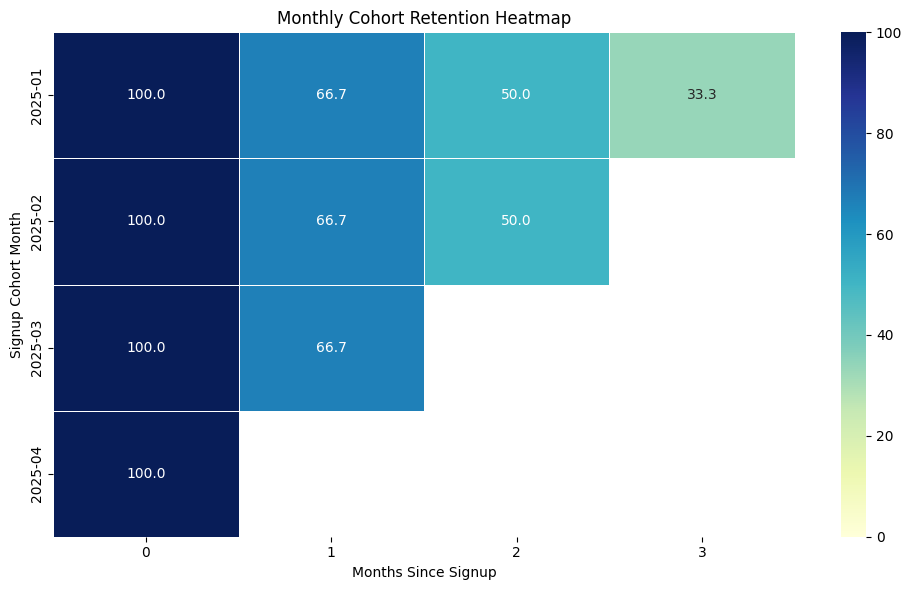

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    retention_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.5
)

plt.title("Monthly Cohort Retention Heatmap")
plt.xlabel("Months Since Signup")
plt.ylabel("Signup Cohort Month")
plt.tight_layout()
plt.show()

In [22]:

import sqlite3
import pandas as pd

# Create a temporary SQL database
conn = sqlite3.connect(":memory:")

# Prepare the dataset for SQL
sql_df = df.copy()
sql_df["cohort_month"] = sql_df["cohort_month"].astype(str)
sql_df["order_month"] = sql_df["order_month"].astype(str)

# Create the orders table
sql_df.to_sql("orders", conn, if_exists="replace", index=False)

print("SQL database and orders table created successfully!")

SQL database and orders table created successfully!


In [23]:

# SQL Query 1: Count unique customers in each signup cohort

query1 = """
SELECT
    cohort_month,
    COUNT(DISTINCT customer_id) AS cohort_size
FROM orders
GROUP BY cohort_month
ORDER BY cohort_month;
"""

# Execute the SQL query using Python
result1 = pd.read_sql_query(query1, conn)

# Display the result
print("COHORT SIZE ANALYSIS")
display(result1)

COHORT SIZE ANALYSIS


,cohort_month,cohort_size
0,2025-01,6
1,2025-02,6
2,2025-03,6
3,2025-04,6


In [24]:

# SQL Query 2: Monthly Active Customers by Cohort

query2 = """
SELECT
    cohort_month,
    order_month,
    COUNT(DISTINCT customer_id) AS active_customers
FROM orders
GROUP BY
    cohort_month,
    order_month
ORDER BY
    cohort_month,
    order_month;
"""

# Execute SQL query
result2 = pd.read_sql_query(query2, conn)

# Display results
print("MONTHLY ACTIVE CUSTOMERS BY COHORT")
display(result2)

MONTHLY ACTIVE CUSTOMERS BY COHORT


,cohort_month,order_month,active_customers
0,2025-01,2025-01,6
1,2025-01,2025-02,4
2,2025-01,2025-03,3
3,2025-01,2025-04,2
4,2025-02,2025-02,6
5,2025-02,2025-03,4
6,2025-02,2025-04,3
7,2025-03,2025-03,6
8,2025-03,2025-04,4
9,2025-04,2025-04,6


In [25]:

# SQL Query 3: Calculate total revenue by signup cohort

query3 = """
SELECT
    cohort_month,
    SUM(order_amount) AS total_revenue
FROM orders
GROUP BY cohort_month
ORDER BY cohort_month;
"""

# Execute SQL query
result3 = pd.read_sql_query(query3, conn)

print("TOTAL REVENUE BY COHORT")
display(result3)

TOTAL REVENUE BY COHORT


,cohort_month,total_revenue
0,2025-01,5705
1,2025-02,4480
2,2025-03,3600
3,2025-04,2220


In [26]:

print("QUERY 1: COHORT SIZE")
display(result1)

print("\nQUERY 2: MONTHLY ACTIVE CUSTOMERS BY COHORT")
display(result2)

print("\nQUERY 3: TOTAL REVENUE BY COHORT")
display(result3)

print("\nSQL analysis completed successfully!")


QUERY 1: COHORT SIZE


,cohort_month,cohort_size
0,2025-01,6
1,2025-02,6
2,2025-03,6
3,2025-04,6



QUERY 2: MONTHLY ACTIVE CUSTOMERS BY COHORT


,cohort_month,order_month,active_customers
0,2025-01,2025-01,6
1,2025-01,2025-02,4
2,2025-01,2025-03,3
3,2025-01,2025-04,2
4,2025-02,2025-02,6
5,2025-02,2025-03,4
6,2025-02,2025-04,3
7,2025-03,2025-03,6
8,2025-03,2025-04,4
9,2025-04,2025-04,6



QUERY 3: TOTAL REVENUE BY COHORT


,cohort_month,total_revenue
0,2025-01,5705
1,2025-02,4480
2,2025-03,3600
3,2025-04,2220



SQL analysis completed successfully!


In [27]:
# BUSINESS INSIGHTS: COHORT RETENTION ANALYSIS

print("BUSINESS INSIGHTS")
print("=" * 45)

# 1. Customer count by signup cohort
print("\n1. CUSTOMER COUNT BY SIGNUP COHORT")
display(result1)

# 2. Monthly customer retention percentage
print("\n2. MONTHLY CUSTOMER RETENTION (%)")
display(retention_table.round(2))

# 3. Revenue by signup cohort
print("\n3. TOTAL REVENUE BY COHORT")
display(result3)

# 4. Identify the highest-revenue cohort
highest_revenue = result3.loc[
    result3["total_revenue"].idxmax()
]

print("\n4. HIGHEST REVENUE COHORT")
print("Cohort Month:", highest_revenue["cohort_month"])
print("Total Revenue:", highest_revenue["total_revenue"])

print("\n" + "=" * 45)
print("COHORT RETENTION ANALYSIS COMPLETED!")

BUSINESS INSIGHTS

1. CUSTOMER COUNT BY SIGNUP COHORT


,cohort_month,cohort_size
0,2025-01,6
1,2025-02,6
2,2025-03,6
3,2025-04,6



2. MONTHLY CUSTOMER RETENTION (%)


cohort_index,0,1,2,3
cohort_month,,,,
2025-01,100.0,66.67,50.0,33.33
2025-02,100.0,66.67,50.0,NaN
2025-03,100.0,66.67,NaN,NaN
2025-04,100.0,NaN,NaN,NaN



3. TOTAL REVENUE BY COHORT


,cohort_month,total_revenue
0,2025-01,5705
1,2025-02,4480
2,2025-03,3600
3,2025-04,2220



4. HIGHEST REVENUE COHORT
Cohort Month: 2025-01
Total Revenue: 5705

COHORT RETENTION ANALYSIS COMPLETED!
